## Importamos las Librerías:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, f1_score, matthews_corrcoef, 
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, auc, accuracy_score
)
from sklearn import metrics  # Para mantener compatibilidad con tu código original
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Establecemos los Parámetros de los Gráficos:

In [3]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Cargamos el Conjunto de Datos:

In [4]:
data = pd.read_csv('~/homicidios/data/final/homicidios_final.csv')
data

,ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,...,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
0,1,32,500 000 a 999 999 habitantes,"Neumonía, no especificada",NaN,Neumonía,Mujer,No,No,No,...,Urbana,De 70 a 74 años,No especificada,Dieciocho días,Diciembre,2022,NaN,NaN,Aguascalientes,Zacatecas
1,1,1,500 000 a 999 999 habitantes,Síndrome de dificultad respiratoria del adulto,NaN,Las demás enfermedades del aparato respiratorio,Mujer,No,No,No,...,Urbana,De 75 a 79 años,No especificada,Doce días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
2,1,1,500 000 a 999 999 habitantes,Enfermedad pulmonar obstructiva crónica con in...,NaN,Enfermedades pulmonares obstructivas crónicas,Mujer,No,No,No,...,Urbana,De 65 a 69 años,No especificada,Diecisiete días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
3,1,1,500 000 a 999 999 habitantes,Desnutrición proteicocalórica leve,NaN,Otras desnutriciones proteinocalóricas,Mujer,No,No,No,...,Urbana,De 90 a 94 años,No especificada,Un día,Enero,2023,NaN,NaN,Aguascalientes,Aguascalientes
4,1,14,500 000 a 999 999 habitantes,Cirrosis hepática alcohólica,NaN,Enfermedad alcohólica del hígado,Hombre,No,No,No,...,Rural,De 45 a 49 años,No aplica,Veintidós días,Diciembre,2022,NaN,NaN,Aguascalientes,Jalisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799864,32,32,20 000 a 29 999 habitantes,"Síndrome de aspiración neonatal, sin otra espe...",NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,No especificado,Diciembre,2023,NaN,NaN,Zacatecas,Zacatecas
799865,32,32,100 000 a 249 999 habitantes,"Kernicterus, no especificado",NaN,Las demás afecciones originadas en el período ...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Cinco días,Junio,2023,NaN,NaN,Zacatecas,Zacatecas
799866,32,32,100 000 a 249 999 habitantes,Síndrome de dificultad respiratoria del recién...,NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Nueve días,Agosto,2023,NaN,NaN,Zacatecas,Zacatecas
799867,32,32,100 000 a 249 999 habitantes,Gastrosquisis,NaN,Otras malformaciones congénitas y deformidades...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Diecinueve días,Septiembre,2023,NaN,NaN,Zacatecas,Zacatecas


## Enraizamos el Proyecto:

In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

## Importamos las Funciones Modulares:

In [6]:
import modules.sustituir_nulos
from modules.sustituir_nulos import sustituir_nulos_pd
from modules.eliminar_variables import eliminar_variables_pd
from modules.eliminar_variables import variables_ml

In [7]:
data = eliminar_variables_pd(df= data, variables= variables_ml)

In [8]:
data.shape

(799869, 50)

## Sustituimos Valores Nulos:

In [9]:
data = sustituir_nulos_pd(df= data, variable= 'lista_mex', text= 'Sin Registros')
data = sustituir_nulos_pd(df= data, variable= 'estado_defuncion_residencia', text= 'Sin Registros')

## Corroboramos Ausencia de Valores Nulos:

In [10]:
data.isnull().sum().sort_values(ascending=False).head(10)

ent_regis     0
ent_resid     0
tloc_ocurr    0
lista_mex     0
sexo          0
afromex       0
conindig      0
lengua        0
cve_lengua    0
nacionalid    0
dtype: int64

## Reducimos el Conjunto de Datos:

In [11]:
data = data[data['tipo_defun']=='Homicidio (Agresión)']

In [14]:
data.shape

(32253, 50)

In [13]:
data['sexo'].value_counts()

sexo
Hombre             28244
Mujer               3739
No especificado      270
Name: count, dtype: int64

## Creamos la Variable Clasificadora:

In [15]:
data['feminmuj'] = ['Sí' if tipo_defun == 'Homicidio (Agresión)' and sexo == 'Mujer' else 'No' 
                    for tipo_defun, sexo in zip(data['tipo_defun'], data['sexo'])]

data['feminmuj'].replace(to_replace='Sí', value=1, inplace=True) 
data['feminmuj'].replace(to_replace='No', value=0, inplace=True)

In [17]:
data['feminmuj'].value_counts()

feminmuj
0    28514
1     3739
Name: count, dtype: int64

In [18]:
data['feminmuj'].isnull().sum()

np.int64(0)

In [13]:
data = data.drop(['tipo_defun', 'sexo'], axis=1)
data

,ent_regis,ent_resid,tloc_ocurr,lista_mex,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,...,capitulo,lista1,area_ur,edad_agru,dia_cert,mes_cert,anio_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,1,1,500 000 a 999 999 habitantes,Agresiones (homicidios),No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Dieciséis días,Enero,2023,Aguascalientes,Aguascalientes,0
847,1,1,500 000 a 999 999 habitantes,Agresiones (homicidios),No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 25 a 29 años,Siete días,Marzo,2023,Aguascalientes,Aguascalientes,0
888,1,1,10 000 a 14 999 habitantes,Agresiones (homicidios),No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,2023,Aguascalientes,Aguascalientes,1
889,1,1,500 000 a 999 999 habitantes,Agresiones (homicidios),No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Veintiséis días,Marzo,2023,Aguascalientes,Aguascalientes,0
900,1,1,500 000 a 999 999 habitantes,Agresiones (homicidios),No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 55 a 59 años,Tres días,Enero,2023,Aguascalientes,Aguascalientes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,32,32,100 000 a 249 999 habitantes,Agresiones (homicidios),No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Rural,De 15 a 19 años,No especificado,Septiembre,2023,Zacatecas,Zacatecas,0
799849,32,32,100 000 a 249 999 habitantes,Agresiones (homicidios),No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,2023,Zacatecas,Zacatecas,1
799850,32,32,100 000 a 249 999 habitantes,Agresiones (homicidios),No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,2023,Zacatecas,Zacatecas,0
799851,32,32,100 000 a 249 999 habitantes,Agresiones (homicidios),No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,2023,Zacatecas,Zacatecas,0


## Análisis de Distribución de Clases:

In [14]:
print("\n=== ANÁLISIS DEL DESBALANCE DE CLASES ===")
class_distribution = data['feminmuj'].value_counts()
print(f"Distribución de clases:")
print(f"Clase 0 (No homicidio de mujer): {class_distribution[0]} ({class_distribution[0]/len(data)*100:.1f}%)")
print(f"Clase 1 (Homicidio de mujer): {class_distribution[1]} ({class_distribution[1]/len(data)*100:.1f}%)")
print(f"Ratio de desbalance: {class_distribution[0]/class_distribution[1]:.1f}:1")


=== ANÁLISIS DEL DESBALANCE DE CLASES ===
Distribución de clases:
Clase 0 (No homicidio de mujer): 28514 (88.4%)
Clase 1 (Homicidio de mujer): 3739 (11.6%)
Ratio de desbalance: 7.6:1


## Procesamiento de Datos:

In [15]:
df_data_processing = data.copy()
df_data_processing = pd.get_dummies(df_data_processing)
print(f"Después de dummificación: {df_data_processing.shape}")

Después de dummificación: (32253, 594)


## Escalado de Datos:

In [16]:
scaler = MinMaxScaler()
df_data_processing_scaled = scaler.fit_transform(df_data_processing)
df_data_processing_scaled = pd.DataFrame(df_data_processing_scaled)
df_data_processing_scaled.columns = df_data_processing.columns

## Separar Característica y Variable Objetivo:

In [17]:
X = df_data_processing_scaled.drop('feminmuj', axis=1)
y = df_data_processing_scaled['feminmuj'].values

## División Estratificada para Mantener Proporción de Clases:

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [47]:
print(f"\nConjuntos de entrenamiento y prueba:")
print(f"X_train: {X_train.shape}, y_train: {np.bincount(y_train.astype(int))}")
print(f"X_test: {X_test.shape}, y_test: {np.bincount(y_test.astype(int))}")


Conjuntos de entrenamiento y prueba:
X_train: (22577, 593), y_train: [19960  2617]
X_test: (9676, 593), y_test: [8554 1122]


## Modelos con Diferentes Enfoques para Desbalance:

In [48]:
print("\n" + "="*60)
print("ENTRENANDO MODELOS CON DIFERENTES ENFOQUES")
print("="*60)


ENTRENANDO MODELOS CON DIFERENTES ENFOQUES


### Modelo Original:

In [ ]:
print("\n1. Modelo Original (sin balanceo)...")
model_original = LogisticRegression(random_state=42, max_iter=1000)
model_original.fit(X_train, y_train)


1. Modelo Original (sin balanceo)...


LogisticRegression(max_iter=1000, random_state=42)

### Modelo Class-Weight Balancedo:

In [50]:
print("2. Modelo con pesos balanceados...")
model_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000
)
model_balanced.fit(X_train, y_train)

2. Modelo con pesos balanceados...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Modelo con SMOTE:

In [51]:
print("3. Modelo con SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Después de SMOTE: {np.bincount(y_train_smote.astype(int))}")

model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

3. Modelo con SMOTE...
Después de SMOTE: [19960 19960]


LogisticRegression(max_iter=1000, random_state=42)

## Función de Evaluación Completa:

In [52]:
def evaluate_model_complete(model, X_test, y_test, model_name="Modelo"):
    """Evaluación completa para modelos con clases desbalanceadas"""
    
    # Predicciones
    prediction_test = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*20} EVALUACIÓN: {model_name.upper()} {'='*20}")
    
    accuracy = accuracy_score(y_test, prediction_test)
    balanced_acc = balanced_accuracy_score(y_test, prediction_test)
    f1 = f1_score(y_test, prediction_test)
    mcc = matthews_corrcoef(y_test, prediction_test)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Balanced Accuracy: {balanced_acc:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"Matthews Correlation Coefficient: {mcc:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Average Precision Score: {avg_precision:.3f}")
    
    # Reporte de clasificación
    print(f"\nReporte de Clasificación:")
    print(classification_report(y_test, prediction_test))
    
    return prediction_test, y_pred_proba, {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'mcc': mcc,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision
    }

## Evaluar Todos los Modelos:

In [53]:
pred_original, proba_original, metrics_original = evaluate_model_complete(
    model_original, X_test, y_test, "Original"
)


==================== EVALUACIÓN: ORIGINAL ====================
Accuracy: 0.884
Balanced Accuracy: 0.539
F1-Score: 0.151
Matthews Correlation Coefficient: 0.175
ROC-AUC: 0.737
Average Precision Score: 0.307

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94      8554
         1.0       0.50      0.09      0.15      1122

    accuracy                           0.88      9676
   macro avg       0.70      0.54      0.54      9676
weighted avg       0.85      0.88      0.85      9676



In [57]:
pred_balanced, proba_balanced, metrics_balanced = evaluate_model_complete(
    model_balanced, X_test, y_test, "Balanceado"
)


==================== EVALUACIÓN: BALANCEADO ====================
Accuracy: 0.742
Balanced Accuracy: 0.680
F1-Score: 0.350
Matthews Correlation Coefficient: 0.257
ROC-AUC: 0.740
Average Precision Score: 0.299

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.94      0.76      0.84      8554
         1.0       0.25      0.60      0.35      1122

    accuracy                           0.74      9676
   macro avg       0.59      0.68      0.59      9676
weighted avg       0.86      0.74      0.78      9676



In [58]:
pred_smote, proba_smote, metrics_smote = evaluate_model_complete(
    model_smote, X_test, y_test, "SMOTE"
)


==================== EVALUACIÓN: SMOTE ====================
Accuracy: 0.738
Balanced Accuracy: 0.677
F1-Score: 0.346
Matthews Correlation Coefficient: 0.251
ROC-AUC: 0.725
Average Precision Score: 0.283

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.84      8554
         1.0       0.24      0.60      0.35      1122

    accuracy                           0.74      9676
   macro avg       0.59      0.68      0.59      9676
weighted avg       0.85      0.74      0.78      9676



## Optmización del Umbral de Desición:

In [28]:
def find_optimal_threshold(y_true, y_proba, metric='f1'):
    """Encuentra el umbral óptimo para maximizar la métrica especificada"""
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    if metric == 'f1':
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
        f1_scores = np.nan_to_num(f1_scores)
        optimal_idx = np.argmax(f1_scores[:-1])  # Excluir último elemento
        optimal_threshold = thresholds[optimal_idx]
        optimal_score = f1_scores[optimal_idx]
        
    elif metric == 'balanced':
        # Buscar punto donde precision ≈ recall
        diff = np.abs(precisions[:-1] - recalls[:-1])
        optimal_idx = np.argmin(diff)
        optimal_threshold = thresholds[optimal_idx]
        optimal_score = (precisions[optimal_idx] + recalls[optimal_idx]) / 2
    
    return optimal_threshold, optimal_score, optimal_idx

In [29]:
print(f"\n{'='*20} OPTIMIZACIÓN DE UMBRAL {'='*20}")


==================== OPTIMIZACIÓN DE UMBRAL ====================


## Optimizar umbral para modelo balanceado (mejor performance):

In [30]:
optimal_threshold, optimal_f1, opt_idx = find_optimal_threshold(
    y_test, proba_balanced, 'f1'
)

In [31]:
print(f"Umbral por defecto: 0.500")
print(f"Umbral óptimo (F1): {optimal_threshold:.3f}")
print(f"F1-Score óptimo: {optimal_f1:.3f}")

Umbral por defecto: 0.500
Umbral óptimo (F1): 0.633
F1-Score óptimo: 0.375


## Aplicar el Umbral Óptimo:

In [32]:
pred_optimal = (proba_balanced >= optimal_threshold).astype(int)

In [33]:
print(f"\nComparación con umbral óptimo:")
print(f"F1-Score (0.5): {f1_score(y_test, pred_balanced):.3f}")
print(f"F1-Score (óptimo): {f1_score(y_test, pred_optimal):.3f}")
print(f"Balanced Accuracy (0.5): {balanced_accuracy_score(y_test, pred_balanced):.3f}")
print(f"Balanced Accuracy (óptimo): {balanced_accuracy_score(y_test, pred_optimal):.3f}")


Comparación con umbral óptimo:
F1-Score (0.5): 0.347
F1-Score (óptimo): 0.375
Balanced Accuracy (0.5): 0.677
Balanced Accuracy (óptimo): 0.668


## Validación Cruzada Estrateficada:

In [34]:
def perform_stratified_cv(model, X, y, model_name="Modelo", cv_folds=5):
    """Validación cruzada estratificada con múltiples métricas"""
    
    scoring = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'f1': 'f1',
        'precision': 'precision',
        'recall': 'recall',
        'roc_auc': 'roc_auc'
    }
    
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_results = cross_validate(
        model, X, y, 
        cv=skf, 
        scoring=scoring,
        return_train_score=False
    )
    
    print(f"\n{'='*15} VALIDACIÓN CRUZADA: {model_name.upper()} {'='*15}")
    for metric in scoring.keys():
        scores = cv_results[f'test_{metric}']
        print(f"{metric.replace('_', ' ').title()}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")
    
    return cv_results

## Validación Cruzada para el Mejor Modelo:

In [35]:
cv_results_balanced = perform_stratified_cv(model_balanced, X, y, "Balanceado")


=============== VALIDACIÓN CRUZADA: BALANCEADO ===============
Accuracy: 0.739 (+/- 0.009)
Balanced Accuracy: 0.681 (+/- 0.018)
F1: 0.350 (+/- 0.018)
Precision: 0.246 (+/- 0.013)
Recall: 0.606 (+/- 0.034)
Roc Auc: 0.736 (+/- 0.019)


## Visualizaciones Mejoradas:

In [36]:
def create_comprehensive_plots(models_data, y_test):
    """Crear visualizaciones completas de evaluación"""
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Matrices de confusión
    for i, (name, pred, _) in enumerate(models_data):
        plt.subplot(3, 4, i+1)
        cm = confusion_matrix(y_test, pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
        disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
        plt.title(f'Matriz de Confusión\n{name}', fontsize=12)
    
    # 2. Curvas ROC
    plt.subplot(3, 4, 4)
    for name, _, proba in models_data:
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Comparación Curvas ROC')
    plt.legend()
    
    # 3. Curvas Precision-Recall
    plt.subplot(3, 4, 8)
    for name, _, proba in models_data:
        precisions, recalls, _ = precision_recall_curve(y_test, proba)
        avg_precision = average_precision_score(y_test, proba)
        plt.plot(recalls, precisions, lw=2, label=f'{name} (AP = {avg_precision:.2f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Comparación Curvas Precision-Recall')
    plt.legend()
    
    # 4. Distribución de probabilidades - Modelo Balanceado
    plt.subplot(3, 4, 12)
    proba_bal = models_data[1][2]  # Probabilidades del modelo balanceado
    plt.hist(proba_bal[y_test==0], bins=50, alpha=0.7, label='Clase 0', density=True)
    plt.hist(proba_bal[y_test==1], bins=50, alpha=0.7, label='Clase 1', density=True)
    plt.axvline(optimal_threshold, color='red', linestyle='--', 
                label=f'Umbral óptimo: {optimal_threshold:.3f}')
    plt.xlabel('Probabilidad Predicha')
    plt.ylabel('Densidad')
    plt.title('Distribución de Probabilidades\n(Modelo Balanceado)')
    plt.legend()
    
    # 5-8. Métricas por umbral para modelo balanceado
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba_bal)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    f1_scores = np.nan_to_num(f1_scores)
    
    plt.subplot(3, 4, 5)
    plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
    plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
    plt.axvline(optimal_threshold, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Umbral')
    plt.ylabel('Valor')
    plt.title('Precision vs Recall por Umbral')
    plt.legend()
    
    plt.subplot(3, 4, 6)
    plt.plot(thresholds, f1_scores[:-1], color='green', linewidth=2)
    plt.axvline(optimal_threshold, color='red', linestyle='--', 
                label=f'Óptimo: {optimal_threshold:.3f}')
    plt.xlabel('Umbral')
    plt.ylabel('F1-Score')
    plt.title('F1-Score por Umbral')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## Preparar Datos para Visualizaciones:

In [37]:
models_visualization_data = [
    ("Original", pred_original, proba_original),
    ("Balanceado", pred_balanced, proba_balanced),
    ("SMOTE", pred_smote, proba_smote)
]

## Creamos Visualizaciones:

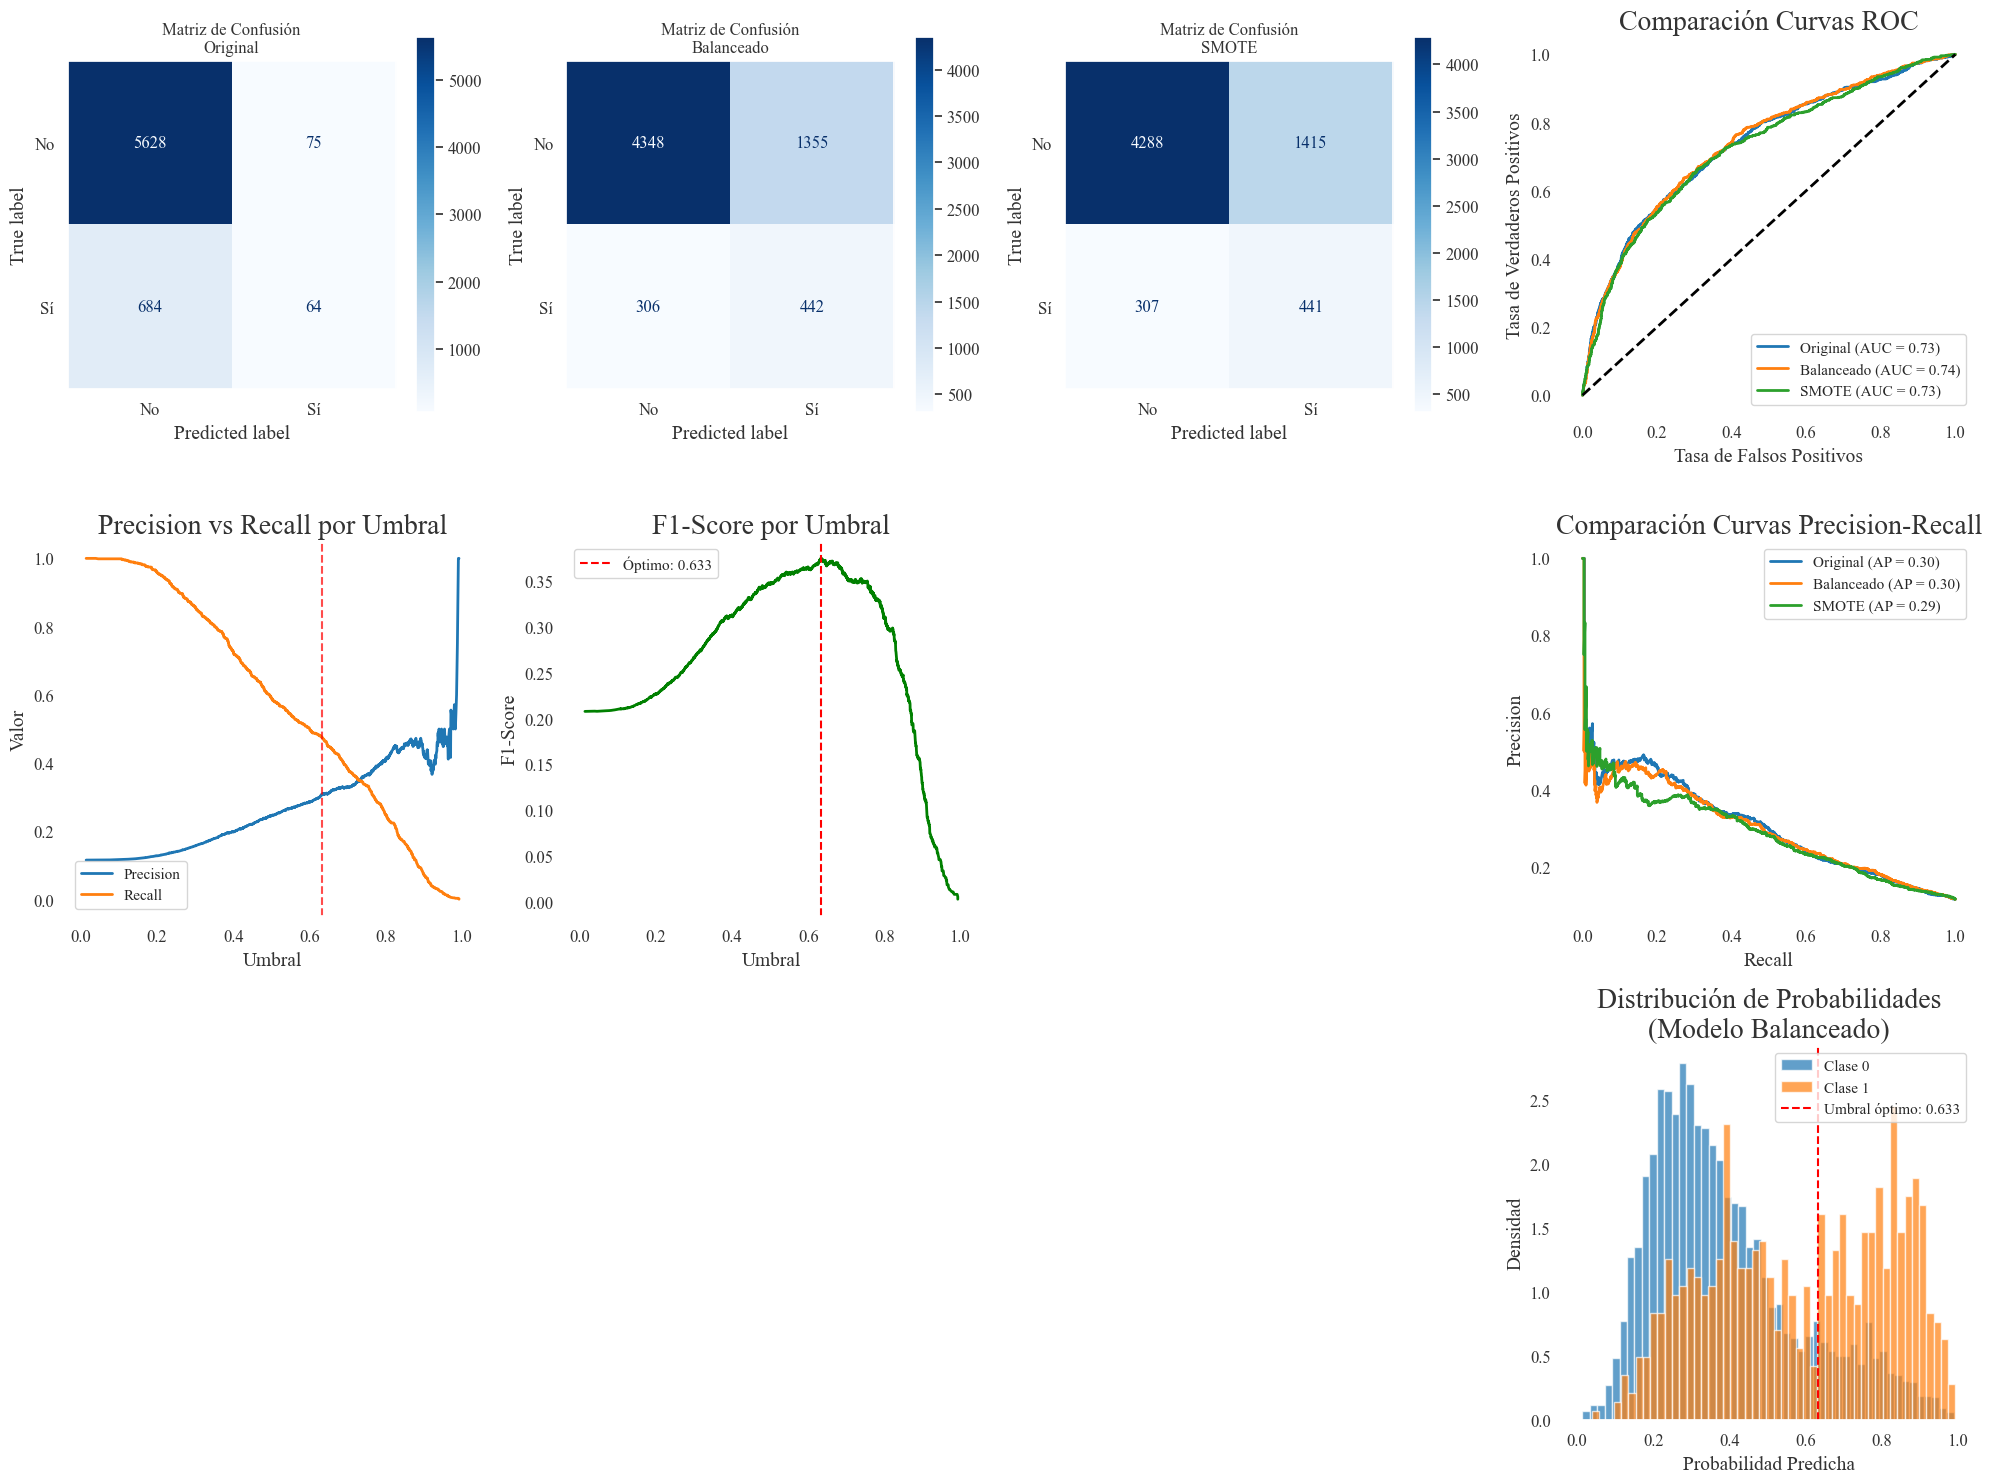

In [38]:
create_comprehensive_plots(models_visualization_data, y_test)

## Resumen Final y Recomendaciones:

In [39]:
print(f"\n{'='*60}")
print("RESUMEN FINAL Y RECOMENDACIONES")
print(f"{'='*60}")

# Comparar métricas principales
metrics_comparison = pd.DataFrame({
    'Original': metrics_original,
    'Balanceado': metrics_balanced,
    'SMOTE': metrics_smote
})

print("\nComparación de métricas:")
print(metrics_comparison.round(3))


RESUMEN FINAL Y RECOMENDACIONES

Comparación de métricas:
                   Original  Balanceado  SMOTE
accuracy              0.882       0.743  0.733
balanced_accuracy     0.536       0.677  0.671
f1_score              0.144       0.347  0.339
mcc                   0.160       0.252  0.241
roc_auc               0.734       0.738  0.726
avg_precision         0.305       0.298  0.287


## Identificar Mejor Modelo Posible:

In [40]:
best_model_idx = metrics_comparison.loc['f1_score'].idxmax()
print(f"\nMejor modelo basado en F1-Score: {best_model_idx}")

print(f"\nRECOMENDACIONES:")
print(f"1. Usar el modelo '{best_model_idx}' como modelo principal")
print(f"2. Aplicar umbral óptimo de {optimal_threshold:.3f} en lugar de 0.5")
print(f"3. Monitorear principalmente: F1-Score, Balanced Accuracy, y Recall para clase 1")
print(f"4. El modelo original tiene sesgo hacia la clase mayoritaria (no detecta homicidios)")
print(f"5. Considerar recolectar más datos de la clase minoritaria si es posible")


Mejor modelo basado en F1-Score: Balanceado

RECOMENDACIONES:
1. Usar el modelo 'Balanceado' como modelo principal
2. Aplicar umbral óptimo de 0.633 en lugar de 0.5
3. Monitorear principalmente: F1-Score, Balanced Accuracy, y Recall para clase 1
4. El modelo original tiene sesgo hacia la clase mayoritaria (no detecta homicidios)
5. Considerar recolectar más datos de la clase minoritaria si es posible


## Asignar el mejor modelo a la variable 'model' para mantener compatibilidad:

In [41]:
if best_model_idx == 'Balanceado':
    model = model_balanced
    prediction_test = pred_balanced
elif best_model_idx == 'SMOTE':
    model = model_smote  
    prediction_test = pred_smote
else:
    model = model_original
    prediction_test = pred_original

print(f"\nVariable 'model' asignada al mejor modelo: {best_model_idx}")
print(f"Variable 'prediction_test' actualizada con las predicciones del mejor modelo")
print(f"Accuracy del mejor modelo: {metrics.accuracy_score(y_test, prediction_test):.4f}")


Variable 'model' asignada al mejor modelo: Balanceado
Variable 'prediction_test' actualizada con las predicciones del mejor modelo
Accuracy del mejor modelo: 0.7425
